In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

url = (
    "https://raw.githubusercontent.com/DataTalksClub/"
    "machine-learning-zoomcamp/main/cohorts/2026/data/"
    "car_fuel_efficiency_2026.csv"
)

columns = [
    "engine_displacement",
    "horsepower",
    "vehicle_weight",
    "model_year",
    "fuel_efficiency_mpg",
]

df = pd.read_csv(url)[columns]

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (10000, 5)


,engine_displacement,horsepower,vehicle_weight,model_year,fuel_efficiency_mpg
0,2180,243.0,3870,2006,31.9
1,2390,272.0,4210,2008,31.3
2,2320,267.0,4240,1996,27.5
3,2130,258.0,4490,1989,28.5
4,2580,304.0,4510,1994,31.0


In [2]:
print("Missing values per column:")
print(df.isna().sum())

print("\nMedian horsepower:", df["horsepower"].median())

Missing values per column:
engine_displacement      0
horsepower             877
vehicle_weight           0
model_year               0
fuel_efficiency_mpg      0
dtype: int64

Median horsepower: 254.0


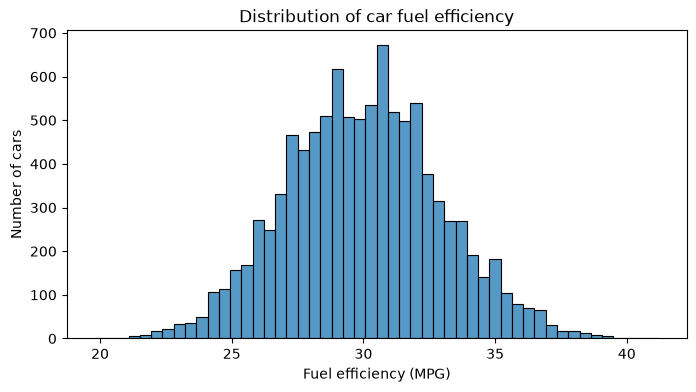

In [3]:
plt.figure(figsize=(8, 4))

sns.histplot(df["fuel_efficiency_mpg"], bins=50)

plt.xlabel("Fuel efficiency (MPG)")
plt.ylabel("Number of cars")
plt.title("Distribution of car fuel efficiency")
plt.show()

In [4]:
n = len(df)
n_val = int(n * 0.2)
n_test = int(n * 0.2)
n_train = n - n_val - n_test

np.random.seed(42)
idx = np.arange(n)
np.random.shuffle(idx)

df_train = df.iloc[idx[:n_train]].copy()
df_val = df.iloc[idx[n_train:n_train + n_val]].copy()
df_test = df.iloc[idx[n_train + n_val:]].copy()

print("Training rows:", len(df_train))
print("Validation rows:", len(df_val))
print("Test rows:", len(df_test))

Training rows: 6000
Validation rows: 2000
Test rows: 2000


In [5]:
features = [
    "engine_displacement",
    "horsepower",
    "vehicle_weight",
    "model_year",
]

def train_linear_regression(X, y):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])

    XTX = X.T @ X
    w = np.linalg.inv(XTX) @ X.T @ y

    return w[0], w[1:]

def rmse(y, y_pred):
    error = y - y_pred
    return np.sqrt((error ** 2).mean())

In [6]:
y_train = df_train["fuel_efficiency_mpg"].to_numpy()
y_val = df_val["fuel_efficiency_mpg"].to_numpy()

# Calculate the mean using training data only
mean_horsepower = df_train["horsepower"].mean()

for label, fill_value in [("With 0", 0), ("With mean", mean_horsepower)]:
    X_train = df_train[features].fillna(fill_value).to_numpy()
    X_val = df_val[features].fillna(fill_value).to_numpy()

    w0, w = train_linear_regression(X_train, y_train)
    y_pred = w0 + X_val @ w

    score = rmse(y_val, y_pred)
    print(label, "RMSE:", round(float(score), 3))

With 0 RMSE: 2.205
With mean RMSE: 2.202


In [7]:
def train_linear_regression_reg(X, y, r=0.0):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])

    XTX = X.T @ X
    XTX = XTX + r * np.eye(XTX.shape[0])

    w = np.linalg.inv(XTX) @ X.T @ y

    return w[0], w[1:]


X_train = df_train[features].fillna(0).to_numpy()
X_val = df_val[features].fillna(0).to_numpy()

results_q4 = []

for r in [0, 0.01, 0.1, 1, 5, 10, 100]:
    w0, w = train_linear_regression_reg(X_train, y_train, r)
    y_pred = w0 + X_val @ w

    score = round(float(rmse(y_val, y_pred)), 4)
    results_q4.append((r, score))

    print(f"r = {r:<6} RMSE = {score:.4f}")

best_r, best_score = min(results_q4, key=lambda result: (result[1], result[0]))
print("\nBest r:", best_r)

r = 0      RMSE = 2.2053
r = 0.01   RMSE = 2.2058
r = 0.1    RMSE = 2.2241
r = 1      RMSE = 2.3492
r = 5      RMSE = 2.4094
r = 10     RMSE = 2.4195
r = 100    RMSE = 2.4292

Best r: 0


In [11]:
scores_q5 = []

for seed in range(10):
    n = len(df)
    n_val = int(n * 0.2)
    n_test = int(n * 0.2)
    n_train = n - n_val - n_test

    np.random.seed(seed)
    idx = np.arange(n)
    np.random.shuffle(idx)

    train = df.iloc[idx[:n_train]]
    val = df.iloc[idx[n_train:n_train + n_val]]
    test = df.iloc[idx[n_train + n_val:]]

    X_train = train[features].fillna(0).to_numpy()
    X_val = val[features].fillna(0).to_numpy()

    y_train = train["fuel_efficiency_mpg"].to_numpy()
    y_val = val["fuel_efficiency_mpg"].to_numpy()

    w0, w = train_linear_regression(X_train, y_train)
    y_pred = w0 + X_val @ w

    score = float(rmse(y_val, y_pred))
    scores_q5.append(score)

    print(f"Seed {seed}: RMSE = {score:.6f}")

std = np.std(scores_q5)

print("\nStandard deviation:", std)
print("round:", round(float(std), 3))

Seed 0: RMSE = 2.239204
Seed 1: RMSE = 2.202113
Seed 2: RMSE = 2.163420
Seed 3: RMSE = 2.204359
Seed 4: RMSE = 2.201880
Seed 5: RMSE = 2.245785
Seed 6: RMSE = 2.269721
Seed 7: RMSE = 2.190795
Seed 8: RMSE = 2.216611
Seed 9: RMSE = 2.207037

Standard deviation: 0.028781274078187116
round: 0.029


In [12]:
# Split again using seed 9
n = len(df)
n_val = int(n * 0.2)
n_test = int(n * 0.2)
n_train = n - n_val - n_test

np.random.seed(9)
idx = np.arange(n)
np.random.shuffle(idx)

train = df.iloc[idx[:n_train]]
val = df.iloc[idx[n_train:n_train + n_val]]
test = df.iloc[idx[n_train + n_val:]]

# Combine training and validation: 8,000 rows
full_train = pd.concat([train, val])

X_full_train = full_train[features].fillna(0).to_numpy()
y_full_train = full_train["fuel_efficiency_mpg"].to_numpy()

X_test = test[features].fillna(0).to_numpy()
y_test = test["fuel_efficiency_mpg"].to_numpy()

# Train and evaluate on the test set
w0, w = train_linear_regression_reg(
    X_full_train, y_full_train, r=0.001
)

y_pred = w0 + X_test @ w
test_score = float(rmse(y_test, y_pred))

print("Test RMSE:", test_score)
print("Rounded to 3 decimals:", round(test_score, 3))

Test RMSE: 2.2358277471917636
Rounded to 3 decimals: 2.236
